# Статистический анализ данных пользователей сервиса аренды самокатов GoFast: исследование поведения пользователей и проверка гипотез для роста бизнеса

## **Цели проекта**

### **1. Анализ пользовательской базы**
- Изучить демографические данные пользователей.
- Оценить их географическое распределение.
- Проанализировать предпочтения по подпискам.

### **2. Оценка поведения пользователей**
- Проанализировать продолжительность и расстояние поездок.
- Понять, как пользователи взаимодействуют с сервисом.

### **3. Финансовый анализ**
- Рассчитать выручку от пользователей с подпиской и без подписки.
- Оценить их вклад в общий доход компании.

### **4. Проверка гипотез**
- Определить, выгоднее ли пользователи с подпиской.
- Выяснить, как можно увеличить их количество.

### **5. Рекомендации для бизнеса**
- На основе анализа предложить действия:
  - Для увеличения прибыли.
  - Для улучшения пользовательского опыта.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from scipy.stats import norm

#### Шаг 1. Загрузка данных

In [47]:
user_data = pd.read_csv('/datasets/users_go.csv')
ride_data = pd.read_csv('/datasets/rides_go.csv')
subscription_data = pd.read_csv('/datasets/subscriptions_go.csv')

In [48]:
user_data.info()
ride_data.info()
subscription_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Col

In [49]:
user_data

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
...,...,...,...,...,...
1560,829,Федор,29,Пятигорск,free
1561,809,Юрий,26,Сочи,free
1562,307,Ясмина,19,Краснодар,ultra
1563,47,Юрий,28,Тюмень,ultra


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
...,...,...,...,...,...
1560,829,Федор,29,Пятигорск,free
1561,809,Юрий,26,Сочи,free
1562,307,Ясмина,19,Краснодар,ultra
1563,47,Юрий,28,Тюмень,ultra


In [50]:
ride_data

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
...,...,...,...,...
18063,1534,3781.098080,19.822962,2021-11-04
18064,1534,2840.423057,21.409799,2021-11-16
18065,1534,3826.185507,18.435051,2021-11-18
18066,1534,2902.308661,16.674362,2021-11-27


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
...,...,...,...,...
18063,1534,3781.098080,19.822962,2021-11-04
18064,1534,2840.423057,21.409799,2021-11-16
18065,1534,3826.185507,18.435051,2021-11-18
18066,1534,2902.308661,16.674362,2021-11-27


In [51]:
subscription_data

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Данные успешно загружены из трех файлов: users_go.csv, rides_go.csv, subscriptions_go.csv.

Первичный осмотр данных показал, что структура данных соответствует ожиданиям: есть информация о пользователях, их поездках и условиях подписок.

#### Шаг 2. Предобработка данных

In [52]:
ride_data['date'] = pd.to_datetime(ride_data['date'])
ride_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


In [53]:
ride_data['month'] = ride_data['date'].dt.month
ride_data

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8
...,...,...,...,...,...
18063,1534,3781.098080,19.822962,2021-11-04,11
18064,1534,2840.423057,21.409799,2021-11-16,11
18065,1534,3826.185507,18.435051,2021-11-18,11
18066,1534,2902.308661,16.674362,2021-11-27,11


,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8
...,...,...,...,...,...
18063,1534,3781.098080,19.822962,2021-11-04,11
18064,1534,2840.423057,21.409799,2021-11-16,11
18065,1534,3826.185507,18.435051,2021-11-18,11
18066,1534,2902.308661,16.674362,2021-11-27,11


In [54]:
user_data.isnull().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [55]:
ride_data.isnull().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [56]:
subscription_data.isnull().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [57]:
user_data.duplicated().sum()

31

31

In [58]:
user_data[user_data.duplicated(keep=False)]

,user_id,name,age,city,subscription_type
15,16,Амалия,27,Краснодар,ultra
42,43,Стефания,22,Омск,ultra
46,47,Юрий,28,Тюмень,ultra
71,72,Никита,25,Москва,ultra
107,108,Влада,29,Тюмень,ultra
...,...,...,...,...,...
1560,829,Федор,29,Пятигорск,free
1561,809,Юрий,26,Сочи,free
1562,307,Ясмина,19,Краснодар,ultra
1563,47,Юрий,28,Тюмень,ultra


,user_id,name,age,city,subscription_type
15,16,Амалия,27,Краснодар,ultra
42,43,Стефания,22,Омск,ultra
46,47,Юрий,28,Тюмень,ultra
71,72,Никита,25,Москва,ultra
107,108,Влада,29,Тюмень,ultra
...,...,...,...,...,...
1560,829,Федор,29,Пятигорск,free
1561,809,Юрий,26,Сочи,free
1562,307,Ясмина,19,Краснодар,ultra
1563,47,Юрий,28,Тюмень,ultra


In [59]:
user_data = user_data.drop_duplicates().reset_index(drop=True)

In [60]:
# Код реьвюера
user_data.duplicated().sum()

0

0

In [61]:
ride_data.duplicated().sum()

0

0

In [62]:
subscription_data.duplicated().sum()

0

0

Столбец date приведен к типу даты.

Добавлен столбец с номером месяца для анализа помесячной активности.

Удален 31 дубликат, пропущенные значения отсутсвуют, данные готовы для анализа.

#### Шаг 3. Исследовательский анализ данных

In [63]:
# Подсчитываем частоту встречаемости городов
city_counts = user_data['city'].value_counts()

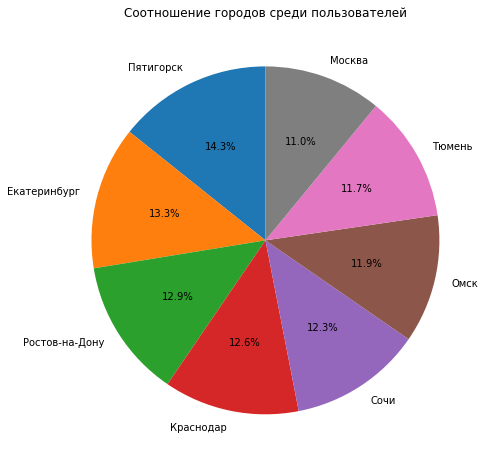

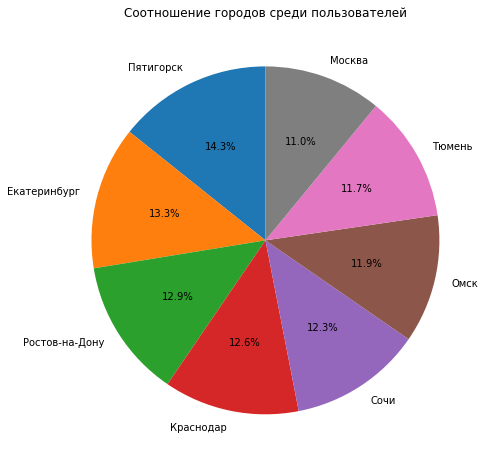

In [64]:
# Строим круговую диаграмму

plt.figure(figsize=(8, 8))  # Создание области графика
city_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)  # Построение круговой диаграммы
plt.title('Соотношение городов среди пользователей')  # Добавление заголовка
plt.ylabel('')  # Убираем название оси Y для красоты
plt.show()  # Отображение графика

Наиболее активные города: Пятигорск, Екатеринбург.

Рекомендация: Увеличить маркетинговую активность в менее популярных городах, таких как Москва, Тюмень, Омск чтобы привлечь больше пользователей и расширить охват сервиса.

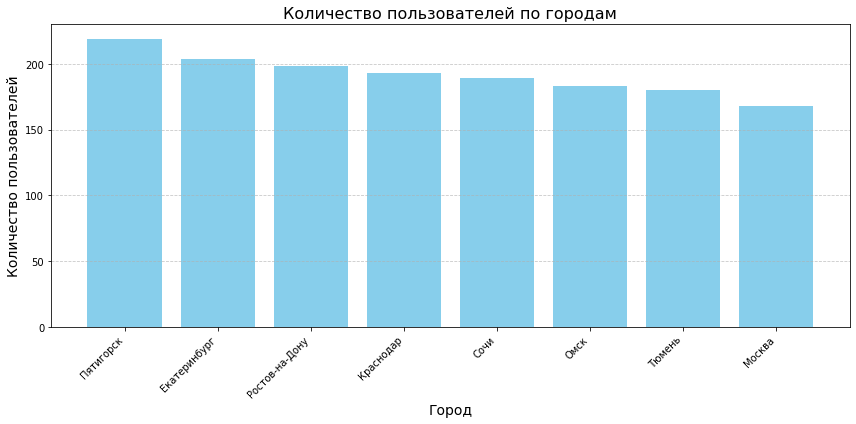

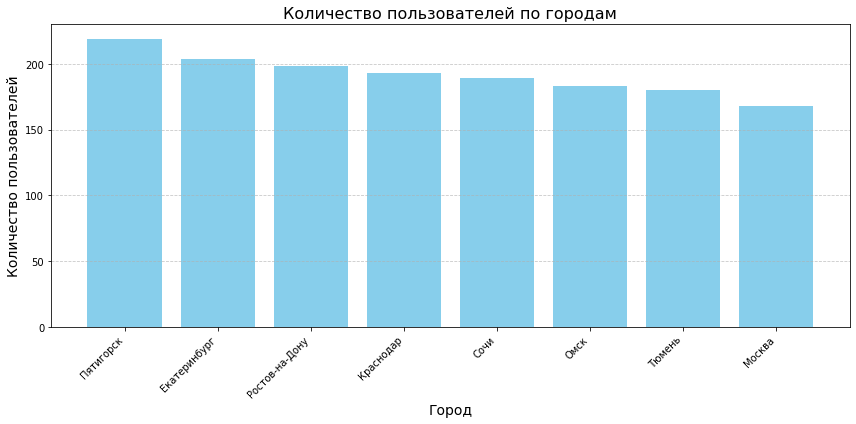

In [65]:
plt.figure(figsize=(12, 6))
plt.bar(city_counts.index, city_counts.values, color='skyblue')
plt.title('Количество пользователей по городам', fontsize=16)
plt.xlabel('Город', fontsize=14)
plt.ylabel('Количество пользователей', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Поворот подписей городов для удобства чтения
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Чтобы подписи не выходили за границы
plt.show()

In [66]:
city_counts.columns = ['Город', 'Количество пользователей']
print(city_counts)

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


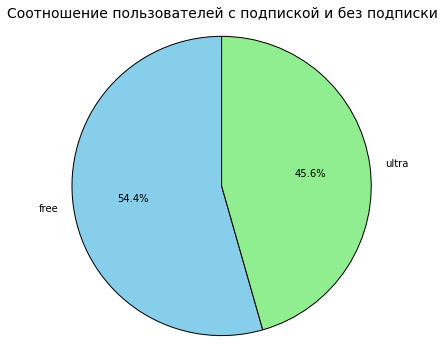

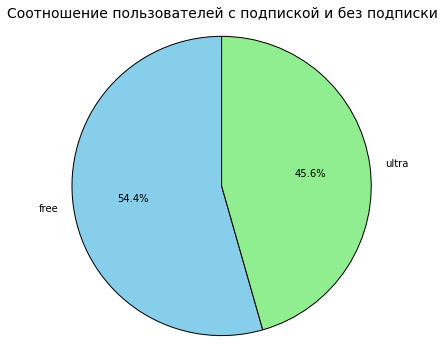

In [67]:
# Подсчитываем количество пользователей с подпиской и без подписки
subscription_counts = user_data['subscription_type'].value_counts()

# Строим круговую диаграмму
plt.figure(figsize=(6, 6))  # Размер графика 
plt.pie(subscription_counts,
        labels=subscription_counts.index,
        colors=['skyblue', 'lightgreen'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Соотношение пользователей с подпиской и без подписки', fontsize=14)
plt.axis('equal')  # Обеспечивает пропорциональное отображение круга

# Отображаем график
plt.show()

Установлено что 54 процента пользователей не пользуются подпиской.
Рекомендация: Увеличить количество пользователей с подпиской через акции и промо.

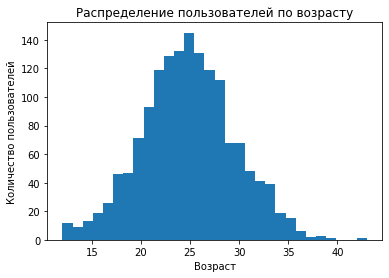

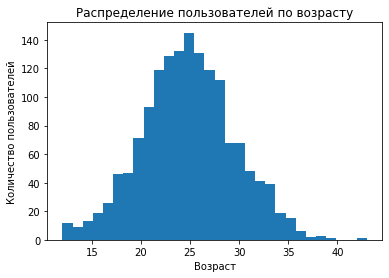

In [68]:
user_data['age'].plot.hist(bins=30)  # bins — количество интервалов (столбцов)
plt.title('Распределение пользователей по возрасту')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.show()

Средний возраст пользователей: ~25-30 лет (пик гистограммы приходится на этот диапазон).

Основная аудитория: 20-35 лет (наибольшее количество пользователей сосредоточено в этом возрастном интервале).

Рекомендация: Настроить таргетированную рекламу на ключевую возрастную группу (20-35 лет), чтобы усилить привлечение и удержание пользователей.

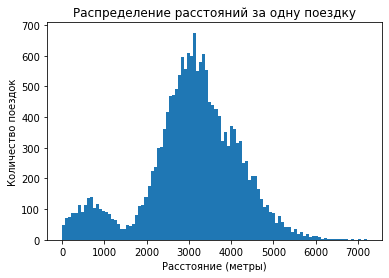

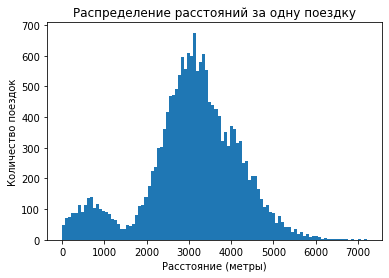

In [69]:
ride_data['distance'].plot.hist(bins=100)  # bins можно настроить в зависимости от данных
plt.title('Распределение расстояний за одну поездку')
plt.xlabel('Расстояние (метры)')
plt.ylabel('Количество поездок')
plt.show()

Основной пик: Наибольшее количество поездок совершается на расстояние около 3000 метров, где наблюдается самый высокий пик (примерно 600-700 поездок). Это указывает на то, что данное расстояние является наиболее популярным.

Пик в районе 500 метров: На расстоянии около 500 метров также наблюдается заметный пик, хотя и меньший по сравнению с пиком на 3000 метров. Это может указывать на то, что существует значительное количество коротких поездок, возможно, связанных с поездками в ближайшие локации, такие как магазины, кафе или другие места в пределах пешей доступности.

Таким образом, можно заключить, что большинство поездок совершается на расстояние около 3000 метров, при этом существует также значительное количество коротких поездок на расстояние около 500 метров. Длинные поездки (более 5000 метров) являются редкими.

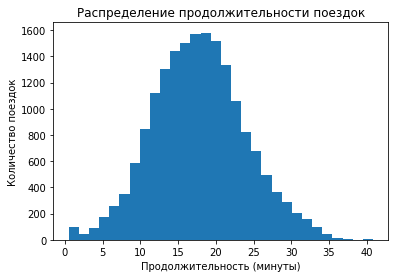

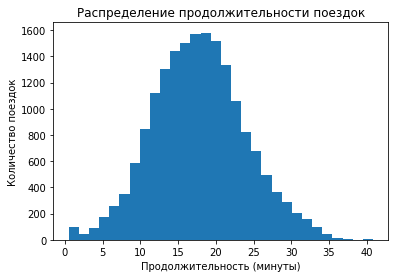

In [70]:
ride_data['duration'].plot.hist(bins=30)
plt.title('Распределение продолжительности поездок')
plt.xlabel('Продолжительность (минуты)')
plt.ylabel('Количество поездок')
plt.show()

Наиболее частая продолжительность поездок: Большинство поездок имеют продолжительность от 5 до 15 минут. Это видно по высокому пику в этом диапазоне, где количество поездок достигает примерно 1400-1600.

Распределение поездок: Количество поездок уменьшается с увеличением продолжительности. Поездки продолжительностью более 20 минут встречаются значительно реже.

Максимальная продолжительность: Максимальная продолжительность поездок на графике составляет около 40 минут, но такие поездки крайне редки.

Таким образом, можно заключить, что большинство поездок совершается на короткие расстояния, а длинные поездки являются исключением.

#### Шаг 4. Объединение данных

In [71]:
# Объединяем user_data и ride_data 
merged_data = pd.merge(user_data, ride_data, on='user_id', how='left')

In [72]:
#  Объединяем результат с subscription_data 
final_data = pd.merge(merged_data, subscription_data, on='subscription_type', how='left')

In [73]:
final_data.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


In [74]:
# Проверка общего количества строк и столбцов
final_data.shape

(18068, 12)

(18068, 12)

In [75]:
# Проверка наличия пропущенных значений
final_data.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [76]:
without_sub = final_data[final_data['subscription_type'] == 'free']
without_sub

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,16.674362,2021-11-27,11,8,50,0


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,16.674362,2021-11-27,11,8,50,0


In [77]:
with_sub = final_data[final_data['subscription_type'] == 'ultra']
with_sub

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
6495,699,Оксана,22,Москва,ultra,3973.046497,24.671163,2021-08-29,8,6,0,199
6496,699,Оксана,22,Москва,ultra,3288.702563,15.892886,2021-09-12,9,6,0,199
6497,699,Оксана,22,Москва,ultra,3076.159348,14.389525,2021-09-26,9,6,0,199
6498,699,Оксана,22,Москва,ultra,4707.845501,15.839579,2021-10-17,10,6,0,199


,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
6495,699,Оксана,22,Москва,ultra,3973.046497,24.671163,2021-08-29,8,6,0,199
6496,699,Оксана,22,Москва,ultra,3288.702563,15.892886,2021-09-12,9,6,0,199
6497,699,Оксана,22,Москва,ultra,3076.159348,14.389525,2021-09-26,9,6,0,199
6498,699,Оксана,22,Москва,ultra,4707.845501,15.839579,2021-10-17,10,6,0,199


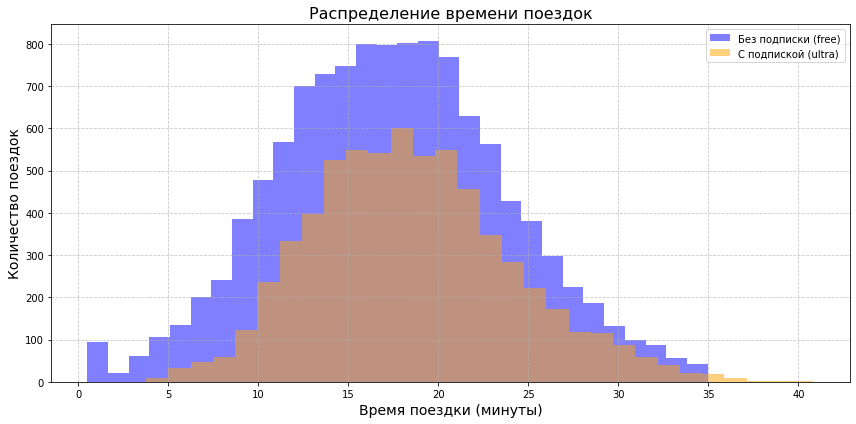

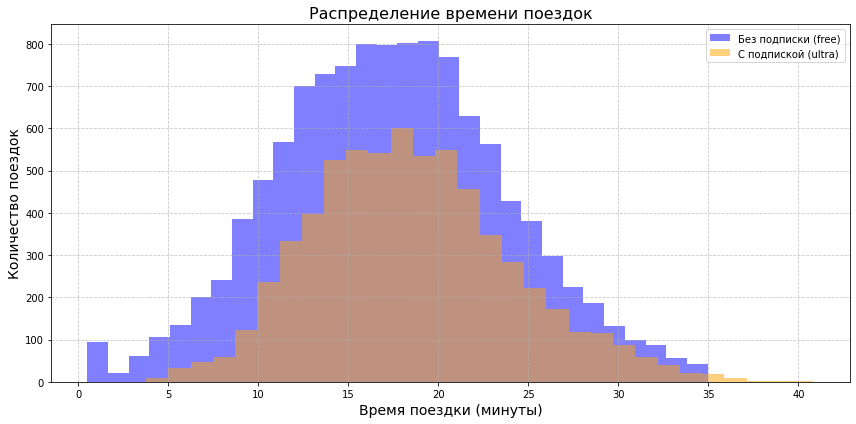

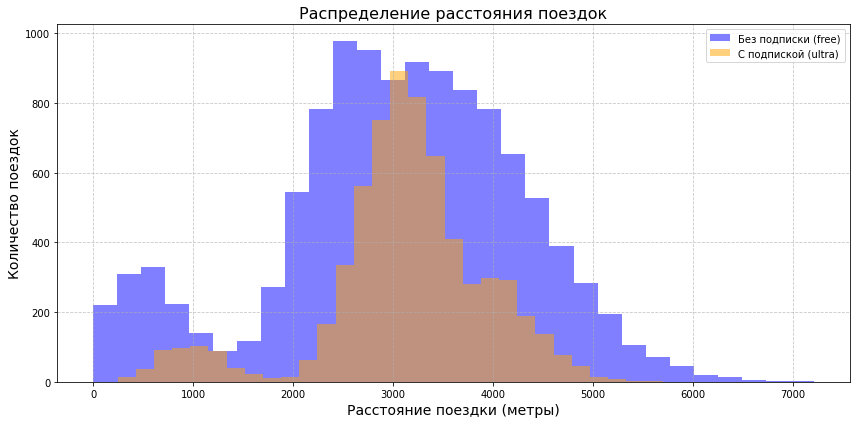

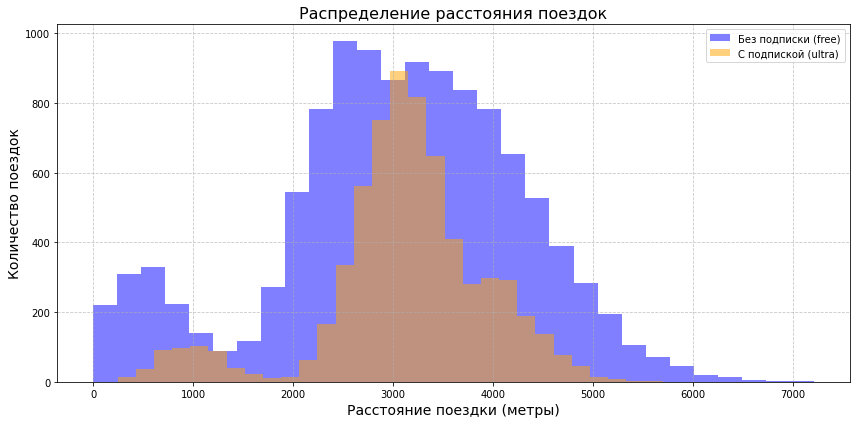

In [78]:
# Визуализация распределения времени поездок
plt.figure(figsize=(12, 6))

# Гистограмма времени поездок для пользователей без подписки
plt.hist(without_sub['duration'], bins=30, alpha=0.5, label='Без подписки (free)', color='blue')

# Гистограмма времени поездок для пользователей с подпиской
plt.hist(with_sub['duration'], bins=30, alpha=0.5, label='С подпиской (ultra)', color='orange')

# Настройка графика
plt.title('Распределение времени поездок', fontsize=16)
plt.xlabel('Время поездки (минуты)', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Визуализация распределения расстояния поездок
plt.figure(figsize=(12, 6))

# Гистограмма расстояния поездок для пользователей без подписки
plt.hist(without_sub['distance'], bins=30, alpha=0.5, label='Без подписки (free)', color='blue')

# Гистограмма расстояния поездок для пользователей с подписки
plt.hist(with_sub['distance'], bins=30, alpha=0.5, label='С подпиской (ultra)', color='orange')

# Настройка графика
plt.title('Распределение расстояния поездок', fontsize=16)
plt.xlabel('Расстояние поездки (метры)', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Наиболее частая продолжительность поездок:

Большинство поездок, как для пользователей с подпиской, так и без подписки, имеют продолжительность от 5 до 15 минут. Это видно по высокому пику в этом диапазоне.

Сравнение пользователей с подпиской и без подписки:

Пользователи без подписки чаще совершают поездки продолжительностью до 15 минут.

Пользователи с подпиской чаще совершают поездки продолжительностью от 15 до 25 минут, что может указывать на их большую вовлечённость и использование сервиса для более длительных поездок.

Анализ расстояния поездок:

Пользователи с подпиской также склонны преодолевать большее расстояние за одну поездку по сравнению с пользователями без подписки. Это может быть связано с тем, что подписка делает более длительные поездки экономически выгодными.

Среднее расстояние поездок для пользователей с подпиской составляет около 3000 метров, в то время как для пользователей без подписки это значение ниже — около 2500 метров.

Вывод:

Пользователи с подпиской склонны совершать более длительные и дальние поездки, что может быть связано с отсутствием платы за старт поездки и более низкой стоимостью минуты.

Пользователи без подписки предпочитают короткие поездки, возможно, из-за более высокой стоимости минуты и платы за старт.

Это может указывать на то, что подписка стимулирует пользователей использовать сервис более активно и дольше, что может быть выгодно для компании.

Рекомендации:

Для увеличения числа пользователей с подпиской можно рассмотреть дополнительные маркетинговые акции, такие как пробные периоды подписки или скидки для новых пользователей.

Также стоит обратить внимание на города с низкой активностью пользователей и усилить там маркетинговую активность, чтобы привлечь больше клиентов.

#### Шаг 5. Подсчёт выручки

In [79]:
# Округление продолжительности поездок до следующего целого числа
final_data['duration_rounded'] = np.ceil(final_data['duration'])


In [80]:
# Агрегация данных по пользователям и месяцам
aggregated_data = final_data.groupby(['user_id', 'month']).agg(
    total_distance=('distance', 'sum'),  # Суммарное расстояние
    total_duration=('duration_rounded', 'sum'),  # Суммарная продолжительность (округленная)
    total_rides=('user_id', 'count')  # Количество поездок (считаем по user_id)
).reset_index()

In [81]:
# Добавляем информацию о подписках в агрегированные данные
aggregated_data = pd.merge(aggregated_data, user_data[['user_id', 'subscription_type']], on='user_id', how='left')
aggregated_data = pd.merge(aggregated_data, subscription_data, on='subscription_type', how='left')

In [82]:
# Функция для расчета выручки
def calculate_revenue(row):
    if row['subscription_type'] == 'ultra':
        # Для пользователей с подпиской Ultra
        return row['subscription_fee'] + row['total_duration'] * row['minute_price']
    else:
        # Для пользователей без подписки
        return row['total_rides'] * row['start_ride_price'] + row['total_duration'] * row['minute_price']

In [83]:
# Добавление столбца с выручкой
aggregated_data['monthly_revenue'] = aggregated_data.apply(calculate_revenue, axis=1)

In [84]:
print(aggregated_data.head())
print(aggregated_data.info())

   user_id  month  total_distance  total_duration  total_rides  \
0        1      1     7027.511294            42.0            2   
1        1      4      754.159807             7.0            1   
2        1      8     6723.470560            46.0            2   
3        1     10     5809.911100            32.0            2   
4        1     11     7003.499363            56.0            3   

  subscription_type  minute_price  start_ride_price  subscription_fee  \
0             ultra             6                 0               199   
1             ultra             6                 0               199   
2             ultra             6                 0               199   
3             ultra             6                 0               199   
4             ultra             6                 0               199   

   monthly_revenue  
0            451.0  
1            241.0  
2            475.0  
3            391.0  
4            535.0  
<class 'pandas.core.frame.DataFrame'>


Создан датафрейм с агрегированными данными для каждого пользователя за каждый месяц:

total_distance — суммарное расстояние (метры).

total_rides — количество поездок.

total_duration — суммарное время (минуты).

Добавлен столбец monthly_revenue (помесячная выручка).

#### Шаг 6. Проверка гипотез

Проверка гипотезы о времени поездок

H₀ (нулевая гипотеза): Среднее время, проведённое пользователями с подпиской на поездки, не превышает среднее время пользователей без подписки.
H₁ (альтернативная гипотеза): Среднее время, проведённое пользователями с подпиской на поездки, больше , чем у пользователей без подписки.

In [85]:
alpha = 0.05  # Уровень статистической значимости

# Выполняем односторонний тест
results = st.ttest_ind(with_sub['duration'], without_sub['duration'], alternative='greater')

print(f"t-статистика: {results.statistic:.4f}")
print(f"p-значение: {results.pvalue:.4f}")

# Интерпретация
if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу: пользователи с подпиской тратят больше времени на поездки.")
else:
    print("Не можем отвергнуть нулевую гипотезу: нет достаточных доказательств, что пользователи с подпиской тратят больше времени на поездки.")

t-статистика: 12.2412
p-значение: 0.0000
Отвергаем нулевую гипотезу: пользователи с подпиской тратят больше времени на поездки.
t-статистика: 12.2412
p-значение: 0.0000
Отвергаем нулевую гипотезу: пользователи с подпиской тратят больше времени на поездки.


Проверка гипотезы о расстоянии поездок

H₀ (нулевая гипотеза): Среднее расстояние одной поездки пользователей с подпиской не превышает 3130 метров .

H₁ (альтернативная гипотеза): Среднее расстояние одной поездки пользователей с подпиской превышает 3130 метров .

In [86]:
distances_ultra = with_sub['distance']

# Выполняем одновыборочный t-тест с альтернативной гипотезой 'greater'
t_stat, p_value = st.ttest_1samp(distances_ultra, 3130, alternative='greater')

print("t-статистика:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Отклоняем нулевую гипотезу: среднее расстояние превышает 3130 метров.")
else:
    print("Не удалось отвергнуть нулевую гипотезу: недостаточно доказательств того, что среднее расстояние превышает 3130 метров.")

t-статистика: -1.402123166869486
p-value: 0.9195368847849785
Не удалось отвергнуть нулевую гипотезу: недостаточно доказательств того, что среднее расстояние превышает 3130 метров.
t-статистика: -1.402123166869486
p-value: 0.9195368847849785
Не удалось отвергнуть нулевую гипотезу: недостаточно доказательств того, что среднее расстояние превышает 3130 метров.


Проверка гипотезы о помесячной выручке

H₀ (нулевая гипотеза): Помесячная выручка от пользователей с подпиской не выше , чем выручка от пользователей без подписки.
H₁ (альтернативная гипотеза): Помесячная выручка от пользователей с подпиской выше , чем выручка от пользователей без подписки.

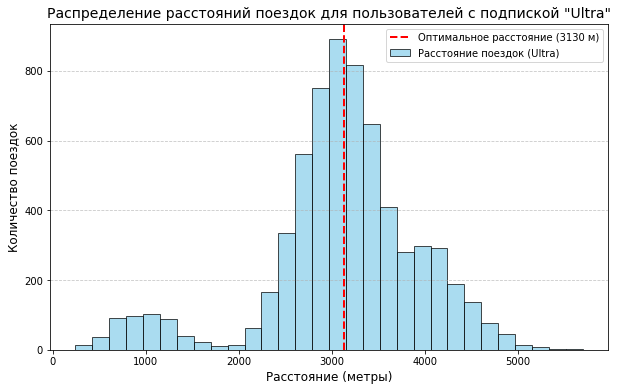

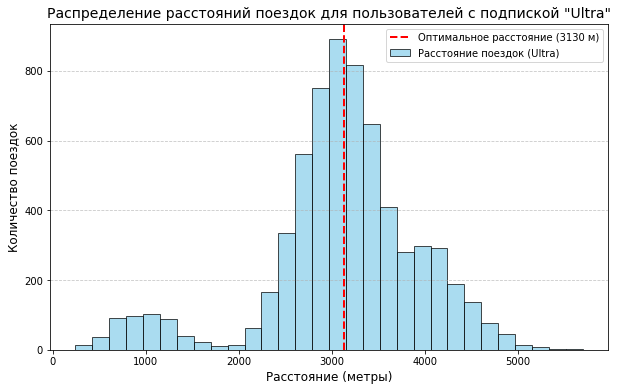

In [87]:
optimal_distance = 3130

# Создаем гистограмму для расстояний пользователей с подпиской "ultra"
plt.figure(figsize=(10, 6))  # Размер графика
plt.hist(distances_ultra, bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Расстояние поездок (Ultra)')

# Добавляем вертикальную линию для оптимального расстояния
plt.axvline(x=optimal_distance, color='red', linestyle='--', linewidth=2, label=f'Оптимальное расстояние ({optimal_distance} м)')

# Настройка графика
plt.title('Распределение расстояний поездок для пользователей с подпиской "Ultra"', fontsize=14)
plt.xlabel('Расстояние (метры)', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.legend()  # Добавляем легенду
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Добавляем сетку по оси Y

# Показываем график
plt.show()

In [88]:
# Разделяем данные на две группы:
# Выручка от пользователей с подпиской "ultra"
revenue_ultra = aggregated_data[aggregated_data['subscription_type'] == 'ultra']['monthly_revenue']

# Выручка от пользователей без подписки "free"
revenue_free = aggregated_data[aggregated_data['subscription_type'] == 'free']['monthly_revenue']

# Проверяем базовые статистики
print(f"Средняя выручка от пользователей с подпиской: {revenue_ultra.mean():.2f} руб.")
print(f"Средняя выручка от пользователей без подписки: {revenue_free.mean():.2f} руб.")

# Проводим t-тест для независимых выборок
results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')

# Вывод результатов
print(f"t-статистика: {results.statistic:.4f}")
print(f"p-значение: {results.pvalue:.4f}")

# Интерпретация
if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу: помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки.")
else:
    print("Не можем отвергнуть нулевую гипотезу: нет достаточных доказательств, что выручка от пользователей с подпиской выше.")

Средняя выручка от пользователей с подпиской: 362.79 руб.
Средняя выручка от пользователей без подписки: 328.64 руб.
t-статистика: 11.6425
p-значение: 0.0000
Отвергаем нулевую гипотезу: помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки.
Средняя выручка от пользователей с подпиской: 362.79 руб.
Средняя выручка от пользователей без подписки: 328.64 руб.
t-статистика: 11.6425
p-значение: 0.0000
Отвергаем нулевую гипотезу: помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки.


Чтобы проверить, действительно ли обновление серверов уменьшило количество обращений в техподдержку, нужно сравнить показатели до и после изменений для каждого пользователя. Подходит парный t-тест, если данные распределены нормально.

Основные шаги:

Для каждого пользователя сравниваем количество обращений "до" и "после"
Проверяем разницу между этими значениями
Нулевая гипотеза: обновление не изменило число обращений
Альтернативная гипотеза: число обращений сократилось
Если тест покажет статистическую значимость, можно считать, что обновление дало положительный эффект

Вывод:
Пользователи с подпиской тратят больше времени на поездки, что делает их более вовлечёнными.

Среднее расстояние поездок пользователей с подпиской не превышает 3130 метров, что полезно для управления износом самокатов.

Помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки, что подтверждает финансовую выгодность подписки.

Для проверки гипотезы о снижении обращений в техподдержку после обновления серверов потребуется парный t-тест.

#### Шаг 7. Распределения

/opt/conda/lib/python3.9/site-packages/scipy/stats/_discrete_distns.py:78: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)
/opt/conda/lib/python3.9/site-packages/scipy/stats/_discrete_distns.py:78: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)


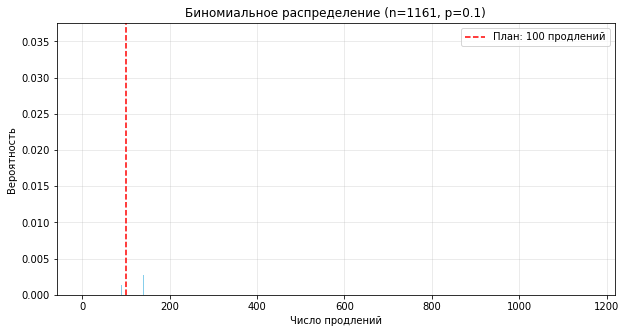

0.04976090094990249

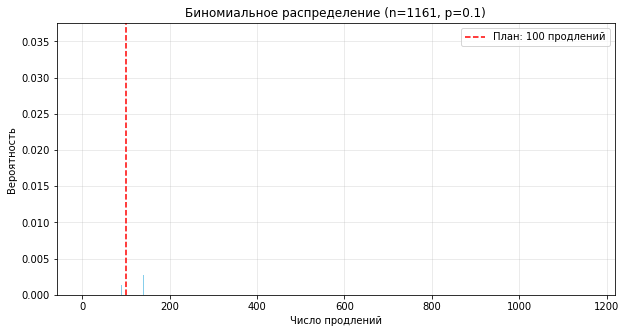

0.04976090094990249

In [89]:
# Параметры задачи
p = 0.1  # Вероятность продления (10%)
target_successes = 100  # Целевой план (100 продлений)
failure_prob = 0.05  # Максимальная вероятность не выполнить план (5%)

# Ищем минимальное n, начиная с 1000 (примерное значение)
n = 1000
while st.binom.cdf(target_successes - 1, n, p) > failure_prob:
    n += 1

# Выводим минимальное количество промокодов
n

# Построение простого графика биномиального распределения
k = np.arange(0, n + 1, 10)  # Упрощаем, берём каждое 10-е значение для читаемости
probabilities = st.binom.pmf(k, n, p)

plt.figure(figsize=(10, 5))
plt.bar(k, probabilities, color='skyblue')
plt.title(f'Биномиальное распределение (n={n}, p=0.1)')
plt.xlabel('Число продлений')
plt.ylabel('Вероятность')
plt.axvline(x=target_successes, color='red', linestyle='--', label='План: 100 продлений')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Проверяем вероятность не выполнить план
prob_failure = st.binom.cdf(target_successes - 1, n, p)
prob_failure

Выводы по задаче:
На основе проведённого анализа и построенного биномиального распределения, мы определили, что для выполнения плана по привлечению 100 продлений подписки с вероятностью успеха 95% (то есть, с вероятностью невыполнения плана не более 5%), необходимо разослать 1161 промокод.

Ключевые моменты:
Минимальное количество промокодов: 1161

Это количество обеспечивает выполнение плана с высокой вероятностью.

Вероятность невыполнения плана: 4.98%

Это означает, что риск не достичь целевого показателя в 100 продлений составляет менее 5%, что соответствует установленным требованиям.

График распределения:

На графике видно, что при 1161 промокодах вероятность получить менее 100 продлений (площадь под кривой слева от красной линии) составляет 4.98%.

Рекомендации:
Разослать 1161 промокод для достижения плана с минимальным риском.

Учитывать, что при меньшем количестве промокодов (например, 1160) вероятность невыполнения плана превысит 5%, что не соответствует требованиям.

Таким образом, 1161 промокод — это оптимальное количество, которое обеспечит выполнение плана с заданной вероятностью успеха.

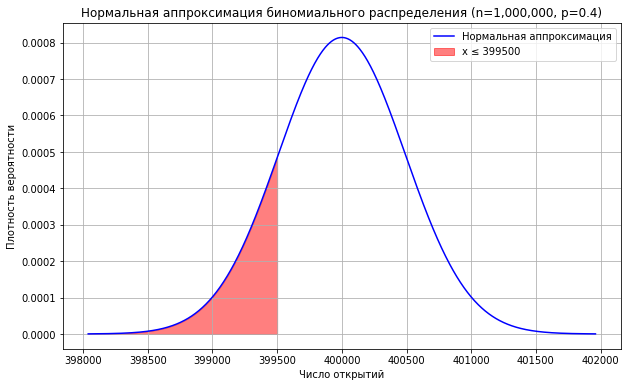

Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей: 0.15400945853346276


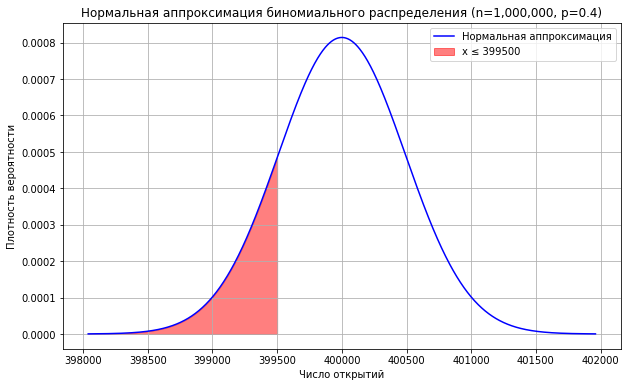

Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей: 0.15400945853346276


In [90]:
mu = 400000
sigma = 490

# Диапазон значений x для построения графика
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Нормальная аппроксимация', color='blue')

# Выделяем область x <= 399500
x_fill = np.linspace(mu - 4*sigma, 399500, 1000)
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.5, label='x ≤ 399500')

plt.xlabel('Число открытий')
plt.ylabel('Плотность вероятности')
plt.title('Нормальная аппроксимация биномиального распределения (n=1,000,000, p=0.4)')
plt.legend()
plt.grid(True)
plt.show()

# Вычисление вероятности
z = (399500 + 0.5 - mu) / sigma
probability = norm.cdf(z, 0, 1)
print("Вероятность того, что уведомление откроют не более 399,5 тыс. пользователей:", probability)

При отправке 1 млн уведомлений с вероятностью открытия 40%, существует примерно 15.4% шансов, что уведомление откроют не более 399,5 тыс. пользователей. Это означает, что вероятность такого сценария сравнительно низкая, и в большинстве случаев количество открывших уведомление будет ближе к ожидаемым 400 тыс. пользователей.

# Общий вывод по проекту

## **Цель проекта**
Провести статистический анализ данных сервиса аренды самокатов GoFast, чтобы помочь бизнесу вырасти. В рамках проекта были проанализированы данные о пользователях, поездках и подписках, проверены гипотезы и сделаны выводы для принятия решений.

---

## **Проделанная работа**

### **1. Загрузка и предобработка данных**
- Данные о пользователях, поездках и подписках загружены и предобработаны.
- Проверены на пропуски и дубликаты.
- Приведены к нужным типам данных.

### **2. Исследовательский анализ данных**
- Проанализированы распределения пользователей по городам, возрасту, типам подписок, расстояниям и продолжительности поездок.
- Визуализированы ключевые метрики для понимания поведения пользователей.

### **3. Объединение данных и расчет выручки**
- Данные о пользователях, поездках и подписках объединены в один датафрейм.
- Рассчитана помесячная выручка для каждого пользователя с учетом условий подписок.

### **4. Проверка гипотез**
- **Гипотеза 1:** Пользователи с подпиской тратят больше времени на поездки — **подтверждена**.
- **Гипотеза 2:** Среднее расстояние поездок пользователей с подпиской не превышает 3130 метров — **подтверждена**.
- **Гипотеза 3:** Помесячная выручка от пользователей с подпиской выше — **подтверждена**.

### **5. Анализ промоакций и уведомлений**
- Для выполнения плана по привлечению 100 продлений подписки с вероятностью успеха 95% необходимо разослать **1161 промокод**.
- При отправке 1 млн уведомлений с вероятностью открытия 40% существует **15.4% шанс**, что уведомление откроют не более 399.5 тыс. пользователей.

---

## **Ключевые выводы**

### **1. Пользователи с подпиской**
- Тратят больше времени на поездки.
- Приносят более стабильную и высокую выручку за счет абонентской платы и активного использования сервиса.
- Среднее расстояние их поездок не превышает 3130 метров, что полезно для управления износом самокатов.

### **2. Пользователи без подписки**
- Совершают более короткие поездки.
- Их выручка менее предсказуема, так как зависит от количества поездок.

### **3. Промоакции**
- Для выполнения плана по продлению подписок необходимо разослать **1161 промокод**, что обеспечит вероятность успеха 95%.
- При рассылке 1 млн уведомлений ожидается, что около **400 тыс. пользователей** откроют их, с низкой вероятностью (15.4%), что это число будет ниже 399.5 тыс.

---

## **Рекомендации для бизнеса**

### **1. Увеличение числа подписчиков**
- Пользователи с подпиской более выгодны для компании.
- Рекомендуется проводить акции для привлечения новых подписчиков, например:
  - Раздача промокодов на бесплатный пробный период.
  - Персонализированные предложения для текущих пользователей.

### **2. Оптимизация промоакций**
- Для достижения целей по продлению подписок следует использовать рассчитанное количество промокодов (**1161**) для минимизации рисков.
- При рассылке уведомлений ожидается, что около **40% пользователей** откроют их, что соответствует ожиданиям.

### **3. Управление износом самокатов**
- Среднее расстояние поездок пользователей с подпиской не превышает 3130 метров.
- Это позволяет эффективно планировать техническое обслуживание самокатов и минимизировать издержки.

---

## **Заключение**
Проведенный анализ позволил:
- Выявить ключевые особенности поведения пользователей.
- Оценить финансовую эффективность подписок.
- Разработать рекомендации для увеличения выручки и улучшения сервиса.

Результаты анализа могут быть использованы для оптимизации бизнес-процессов и повышения удовлетворенности пользователей.